# Etapa 0

Carregamento de bibliotecas

In [1]:
import cv2
import random
from pathlib import Path

# Etapa 1

Foram coletadas 6 imagens em resolução 4032x3024. Para melhor performance, as imagens serão redimensionadas com o fator x0.25, utilizando Lanczos.

## Redimensionamento

In [2]:
from src.resize import resize_images

images_raw_dir = Path("./data/raw/")
images_processed_dir = Path("./data/processed")

resize_images(images_raw_dir, images_processed_dir, 0.25)

IMG_0301.JPG: 4032x3024 -> 1008x756
IMG_0302.JPG: 4032x3024 -> 1008x756
IMG_0303.JPG: 4032x3024 -> 1008x756
IMG_0304.JPG: 4032x3024 -> 1008x756
IMG_0305.JPG: 4032x3024 -> 1008x756
IMG_0306.JPG: 4032x3024 -> 1008x756
IMG_0307.JPG: 4032x3024 -> 1008x756
IMG_0315.JPG: 4032x3024 -> 1008x756


## Carregregamento das imagens

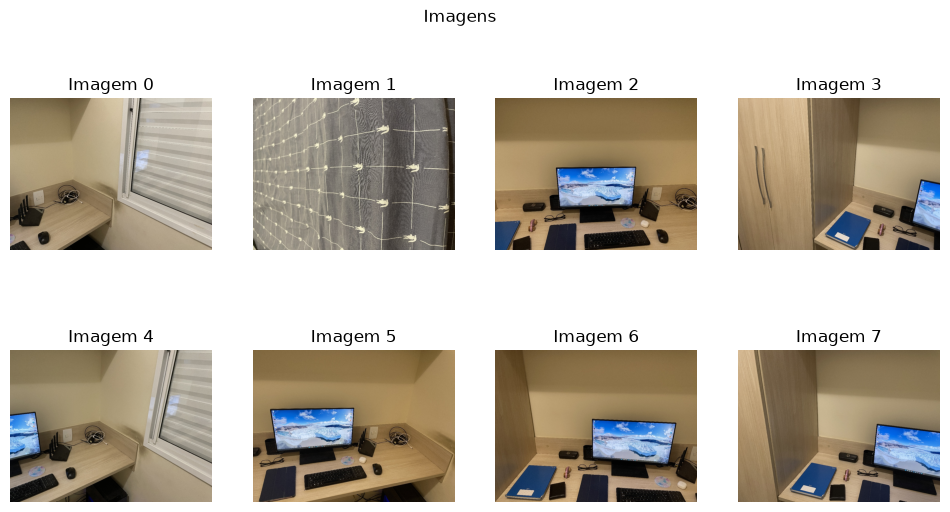

In [3]:
from src.visualization import plot_image_grid

images = []
for image_path in sorted(images_processed_dir.iterdir()):
    image = cv2.imread(image_path)
    images.append(image)

random.seed(2026)
random.shuffle(images)
plot_image_grid(images)

## Panorama do OpenCV

Este é o panorama criado utilizando a implementação nativa do OpenCV, apenas para critério de comparação.

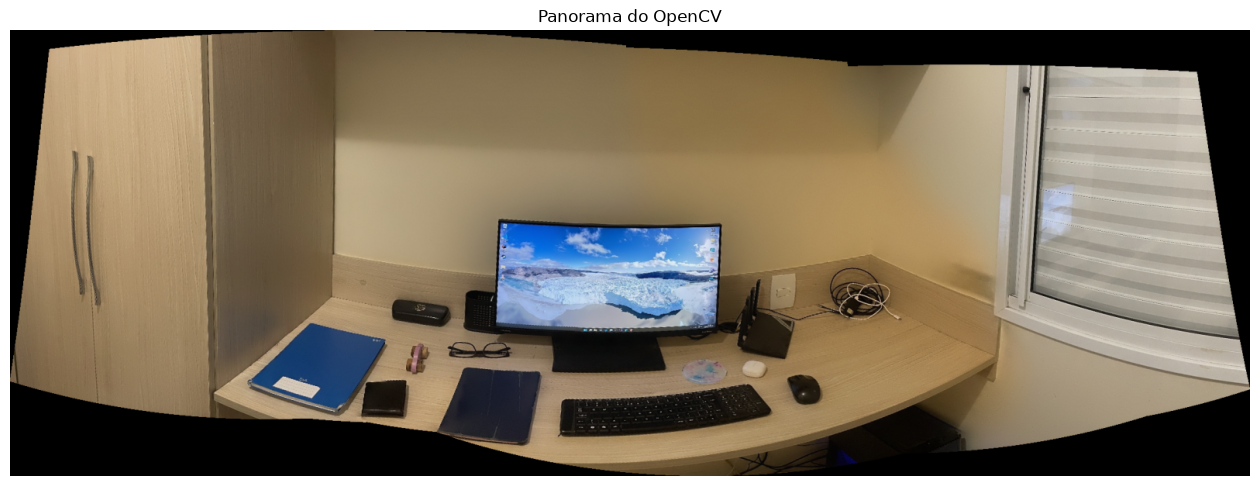

In [4]:
from src.visualization import plot_image

stitcher = cv2.Stitcher_create(cv2.Stitcher_PANORAMA)
status, panorama_opencv = stitcher.stitch(images)

if status == cv2.Stitcher_OK:
    plot_image(panorama_opencv, "Panorama do OpenCV")
    cv2.imwrite("results/panorama_opencv.jpg", panorama_opencv)
else:
    print("O Stitcher falhou.")

# Etapa 2

Detecção de keypoints com SIFT e ORB

Detector: sift
Número de keypoints: 535
Formato dos descritores: (535, 128)
Número de keypoints: 3000
Formato dos descritores: (3000, 128)
Número de keypoints: 1004
Formato dos descritores: (1004, 128)
Número de keypoints: 476
Formato dos descritores: (476, 128)
Número de keypoints: 754
Formato dos descritores: (754, 128)
Número de keypoints: 1142
Formato dos descritores: (1142, 128)
Número de keypoints: 899
Formato dos descritores: (899, 128)
Número de keypoints: 820
Formato dos descritores: (820, 128)


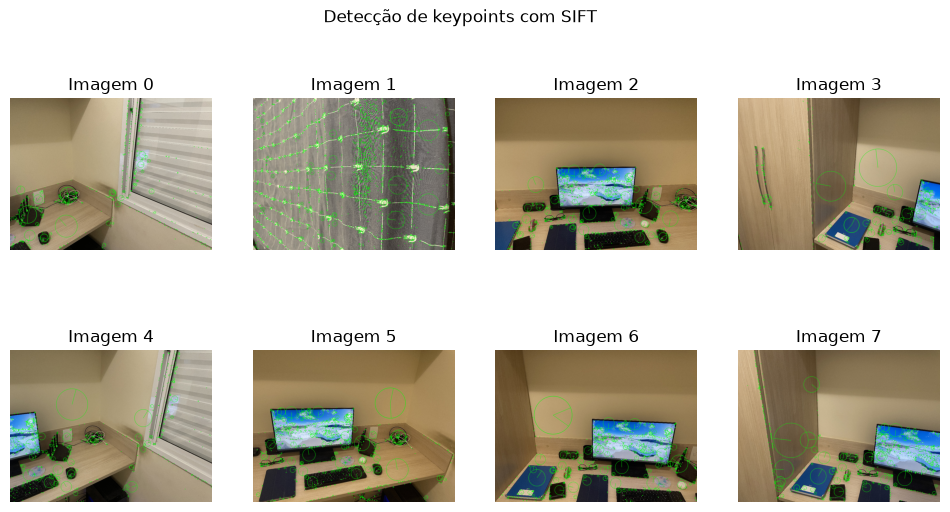

In [5]:
from src.features import draw_keypoints

images_sift = draw_keypoints(images, "sift") # array de dicts contendo { "image": (valor),  "keypoints": (valor), "descriptors": (valor) }
plot_image_grid([item["image"] for item in images_sift], "Detecção de keypoints com SIFT") # extrai "image" de cada item no array

Detector: orb
Número de keypoints: 500
Formato dos descritores: (500, 32)
Número de keypoints: 500
Formato dos descritores: (500, 32)
Número de keypoints: 500
Formato dos descritores: (500, 32)
Número de keypoints: 500
Formato dos descritores: (500, 32)
Número de keypoints: 500
Formato dos descritores: (500, 32)
Número de keypoints: 500
Formato dos descritores: (500, 32)
Número de keypoints: 500
Formato dos descritores: (500, 32)
Número de keypoints: 500
Formato dos descritores: (500, 32)


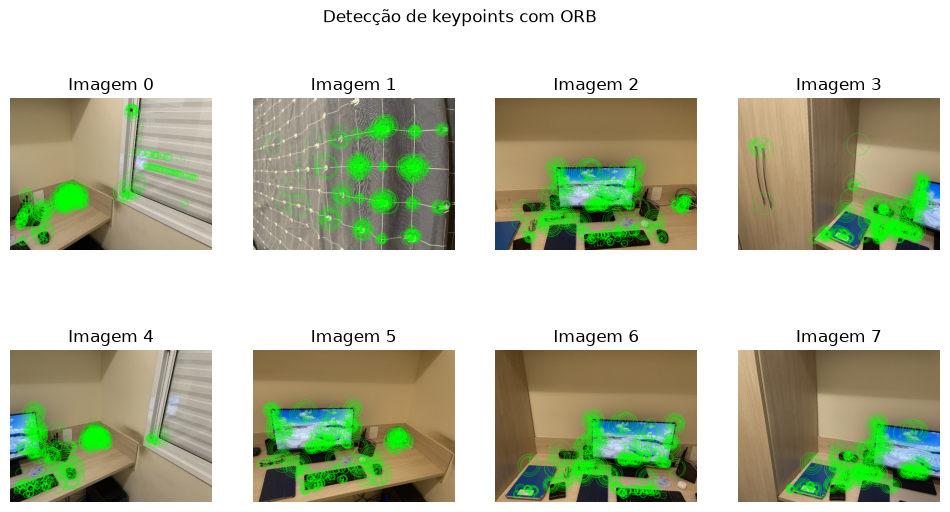

In [6]:
images_orb = draw_keypoints(images, "orb") # array de dicts contendo { "image": (valor),  "keypoints": (valor), "descriptors": (valor) }
plot_image_grid([item["image"] for item in images_orb], "Detecção de keypoints com ORB") # extrai "image" de cada item no array

# Etapa 3

In [7]:
from src.matching import match_all_images

RATIO_THRESHOLD = 0.75

# match_all_images retorna dois dicionários. A estrutura do dicionário é 
# { (i, j): matches } onde i e j são índices de imagem, e matches é uma lista de matches.
# i sempre é menor que j.
matches_matrix, lowe_matrix= match_all_images(
    [item["descriptors"] for item in images_sift], # extrai "descriptors" de cada item no array
    method="sift",
    ratio=RATIO_THRESHOLD
)

print("Sem o teste de Lowe")
for i in range(len(matches_matrix)):
    for j in range(len(matches_matrix[i])):
        print(
            f"Imagem {i} <-> Imagem {j}: "
            f"{len(matches_matrix[i][j])} matches"
        )

print("Com o teste de Lowe")
for i in range(len(lowe_matrix)):
    for j in range(len(lowe_matrix[i])):
        print(
            f"Imagem {i} <-> Imagem {j}: "
            f"{len(lowe_matrix[i][j])} matches"
        )

Sem o teste de Lowe
Imagem 0 <-> Imagem 0: 0 matches
Imagem 0 <-> Imagem 1: 535 matches
Imagem 0 <-> Imagem 2: 535 matches
Imagem 0 <-> Imagem 3: 535 matches
Imagem 0 <-> Imagem 4: 535 matches
Imagem 0 <-> Imagem 5: 535 matches
Imagem 0 <-> Imagem 6: 535 matches
Imagem 0 <-> Imagem 7: 535 matches
Imagem 1 <-> Imagem 0: 3000 matches
Imagem 1 <-> Imagem 1: 0 matches
Imagem 1 <-> Imagem 2: 3000 matches
Imagem 1 <-> Imagem 3: 3000 matches
Imagem 1 <-> Imagem 4: 3000 matches
Imagem 1 <-> Imagem 5: 3000 matches
Imagem 1 <-> Imagem 6: 3000 matches
Imagem 1 <-> Imagem 7: 3000 matches
Imagem 2 <-> Imagem 0: 1004 matches
Imagem 2 <-> Imagem 1: 1004 matches
Imagem 2 <-> Imagem 2: 0 matches
Imagem 2 <-> Imagem 3: 1004 matches
Imagem 2 <-> Imagem 4: 1004 matches
Imagem 2 <-> Imagem 5: 1004 matches
Imagem 2 <-> Imagem 6: 1004 matches
Imagem 2 <-> Imagem 7: 1004 matches
Imagem 3 <-> Imagem 0: 476 matches
Imagem 3 <-> Imagem 1: 476 matches
Imagem 3 <-> Imagem 2: 476 matches
Imagem 3 <-> Imagem 3: 0 ma

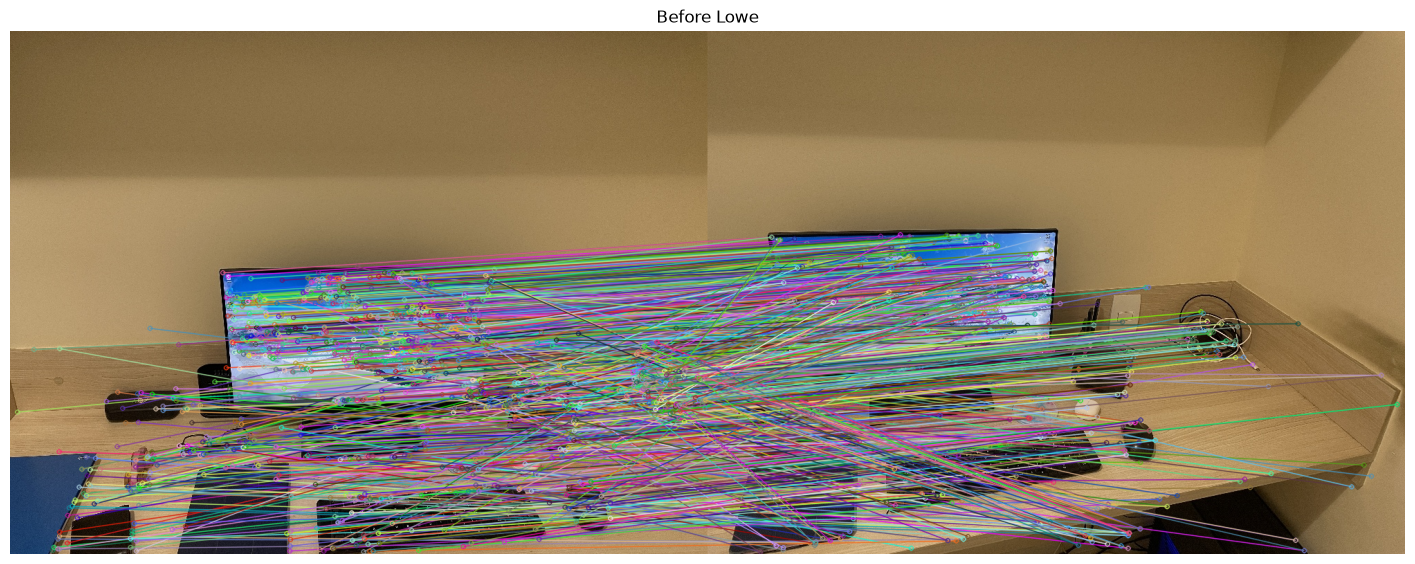

In [8]:
from src.visualization import plot_matches

i = 2
j = 5

plot_matches(images[i], # imagem sem os keypoints sobrepostos
            images_sift[i]["keypoints"], # keypoints
            images[j], 
            images_sift[j]["keypoints"],
            matches_matrix[i][j], # matches associados ao par de imagens
            "Before Lowe")

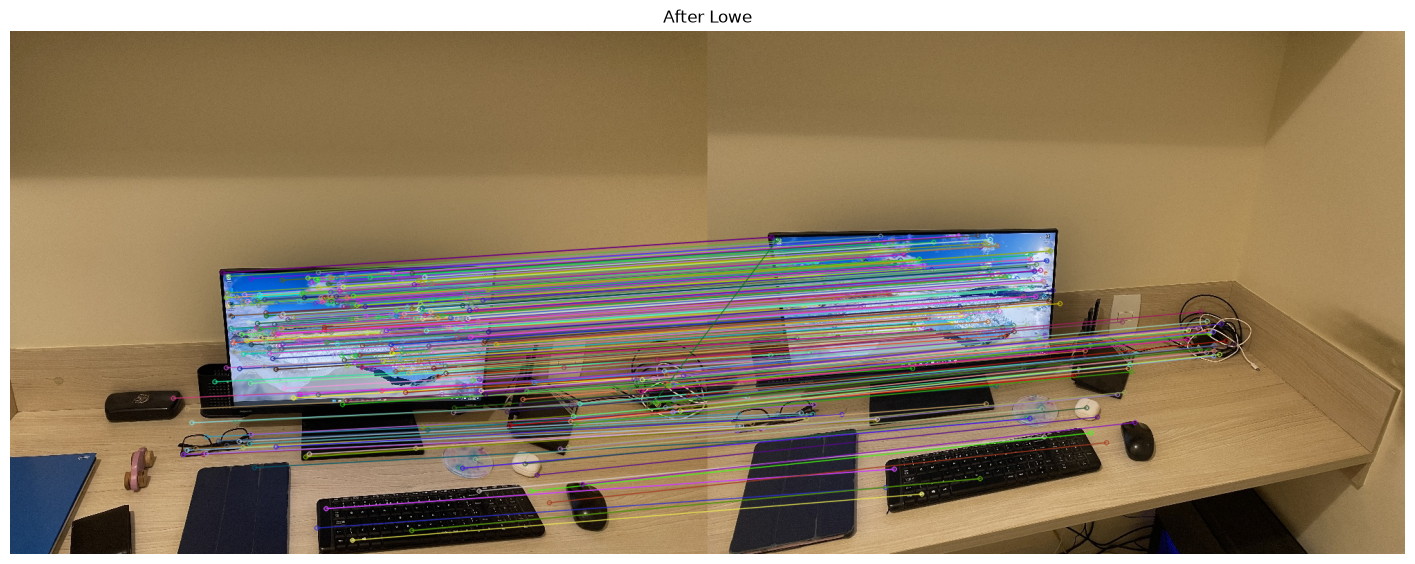

In [9]:
plot_matches(images[i], # imagem sem os keypoints sobrepostos
            images_sift[i]["keypoints"], # keypoints
            images[j], 
            images_sift[j]["keypoints"],
            lowe_matrix[i][j], # matches associados ao par de imagens, filtrados com teste da razão
            "After Lowe")

# Etapa 4

Ordenação automática

[0, 4, 5, 2, 6, 7, 3]


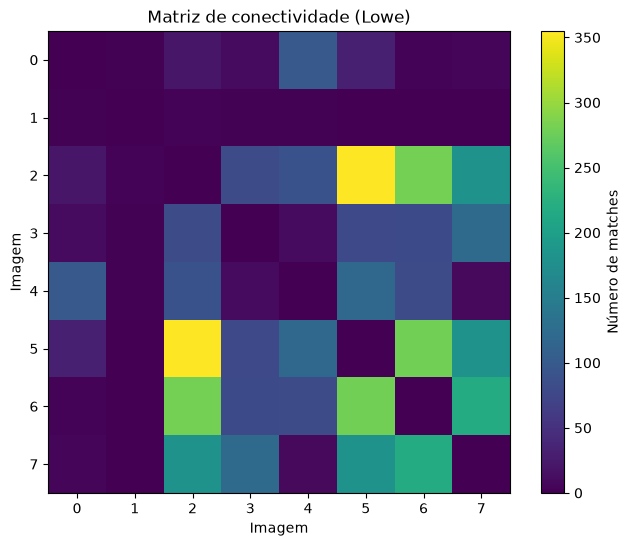

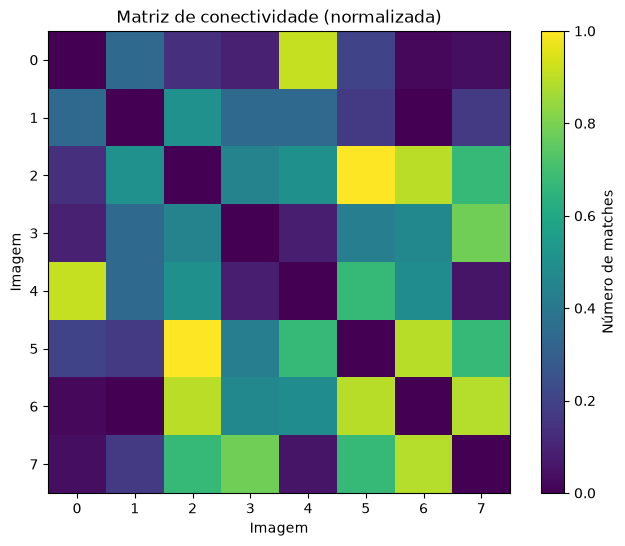

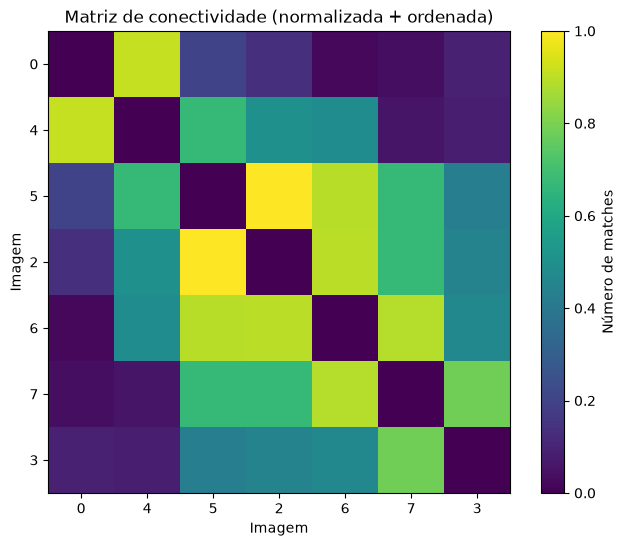

In [10]:
from src.ordering import infer_order
from src.visualization import plot_matrix

order, count_matrix, normalized_matrix, _, _, _ = infer_order(lowe_matrix) 

print(order)
plot_matrix(count_matrix, title="Matriz de conectividade (Lowe)")
plot_matrix(normalized_matrix, title="Matriz de conectividade (normalizada)")
plot_matrix(normalized_matrix, title="Matriz de conectividade (normalizada + ordenada)", order=order)

# Etapa 5

Homografia e Alinhamento

In [11]:
from src.homography import estimate_all_homographies

homographies, homography_metrics = estimate_all_homographies(lowe_matrix, [item["keypoints"] for item in images_sift], order)

for metric in homography_metrics:

    print(
        f"{metric['src_index']} -> {metric['dst_index']} | "
        f"matches = {metric['num_matches']} | "
        f"inliers = {metric['num_inliers']} | "
        f"inlier rate = {metric['inlier_rate']:.2%} | "
        f"erro médio = "
        f"{metric['mean_reprojection_error']:.2f} px"
    )

Processando: imagem 0 -> imagem 4


/home/luizl/repositorios/visao-computacional-mc919/.venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2767: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
/home/luizl/repositorios/visao-computacional-mc919/panoramas/src/homography.py:160: RuntimeWarning: overflow encountered in scalar power
  J[2 * i] = [x / d, y / d, 1 / d, 0, 0, 0, -x * a / d**2, -y * a / d**2]
/home/luizl/repositorios/visao-computacional-mc919/panoramas/src/homography.py:167: RuntimeWarning: overflow encountered in scalar power
  J[2 * i + 1] = [0, 0, 0, x / d, y / d, 1 / d, -x * b / d**2, -y * b / d**2]


Processando: imagem 4 -> imagem 5
Processando: imagem 5 -> imagem 2
Processando: imagem 2 -> imagem 6
Processando: imagem 6 -> imagem 7
Processando: imagem 7 -> imagem 3
0 -> 4 | matches = 99 | inliers = 80 | inlier rate = 80.81% | erro médio = 1.03 px
4 -> 5 | matches = 120 | inliers = 83 | inlier rate = 69.17% | erro médio = 0.76 px
5 -> 2 | matches = 355 | inliers = 336 | inlier rate = 94.65% | erro médio = 0.79 px
2 -> 6 | matches = 281 | inliers = 238 | inlier rate = 84.70% | erro médio = 0.79 px
6 -> 7 | matches = 218 | inliers = 180 | inlier rate = 82.57% | erro médio = 1.01 px
7 -> 3 | matches = 123 | inliers = 98 | inlier rate = 79.67% | erro médio = 0.90 px


Par analisado: imagem 0 -> imagem 4
Processando: imagem 0 -> imagem 4
Processando: imagem 0 -> imagem 4
Processando: imagem 0 -> imagem 4


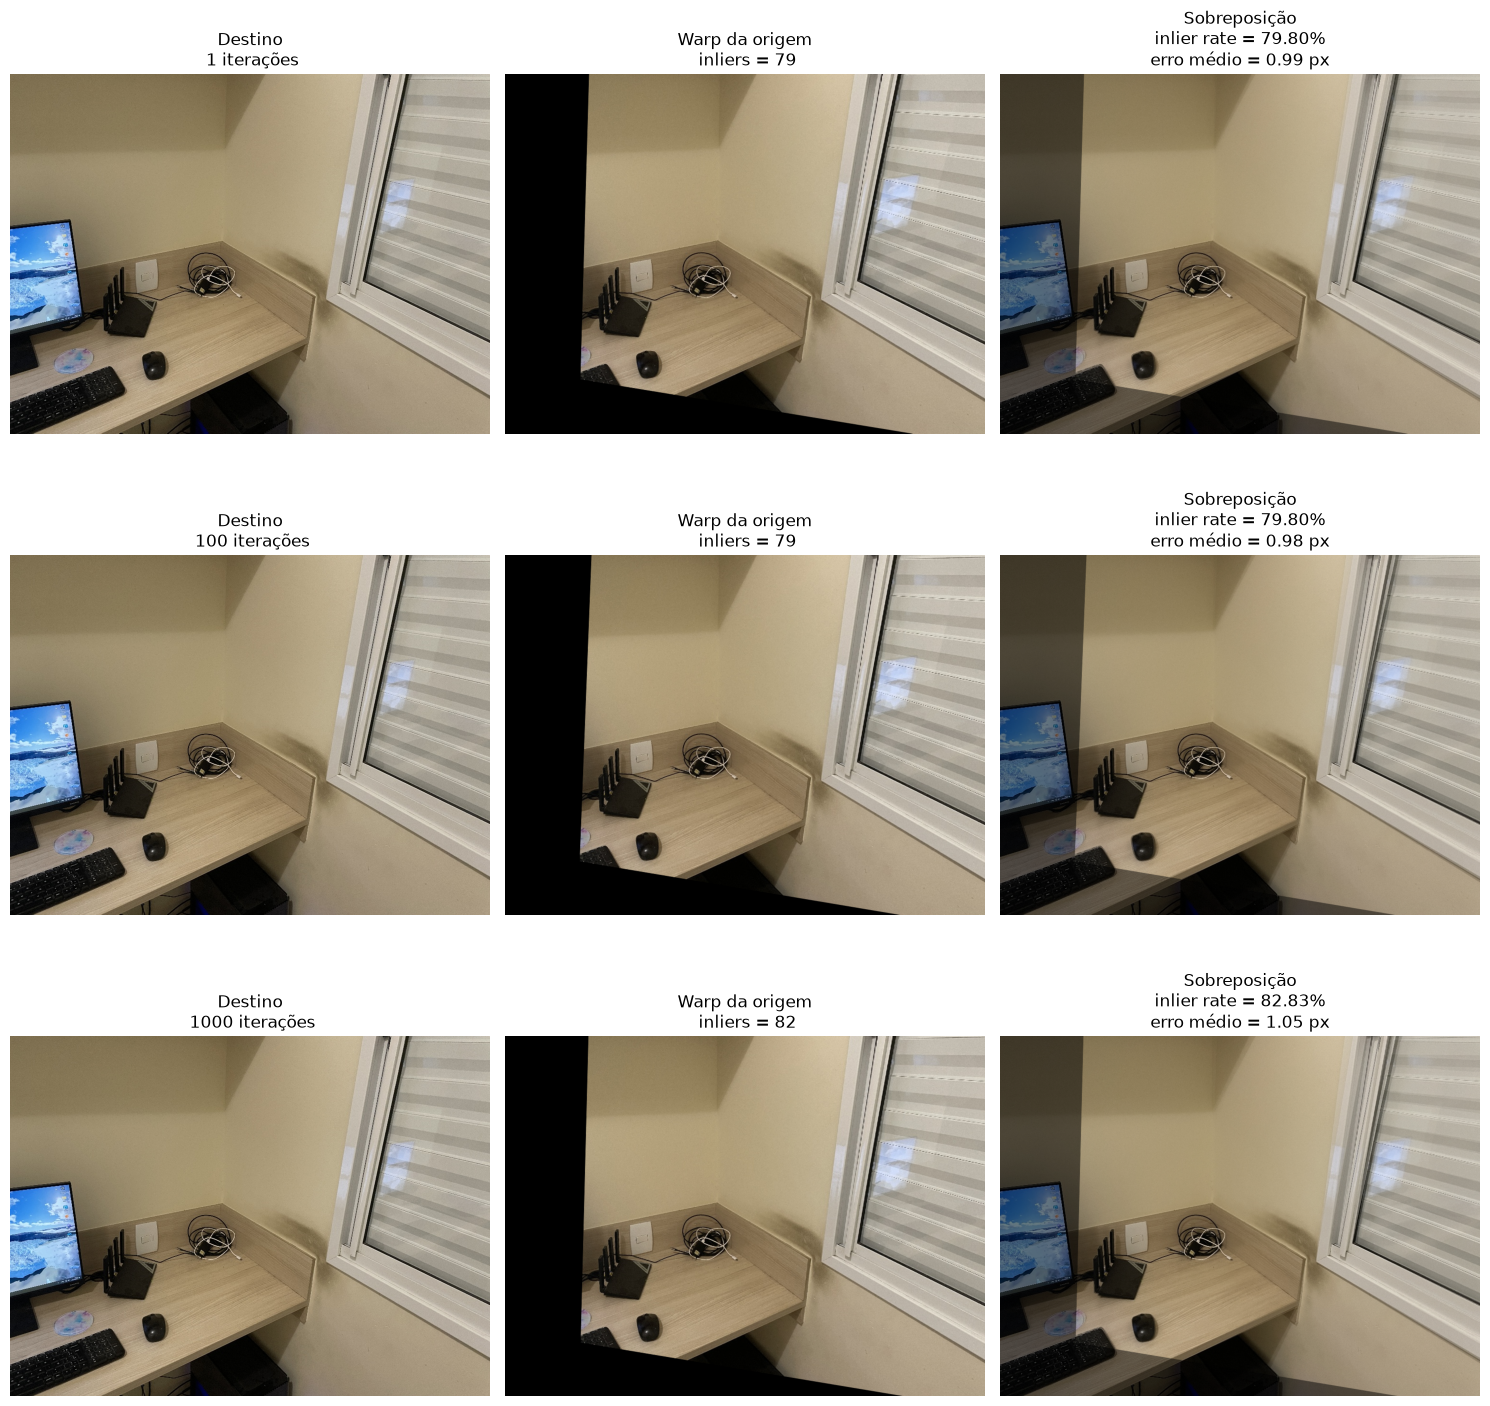

In [12]:
from src.visualization import plot_iterations

i = 0
j = 4

print(f"Par analisado: imagem {i} -> imagem {j}")
iteration_values = [1, 100, 1000]
results = []

for num_iterations in iteration_values:
    H, pair_metrics = estimate_all_homographies(lowe_matrix, [item["keypoints"] for item in images_sift], [i, j])

    results.append({
        "iterations": num_iterations,
        "H": H[0],
        "metrics": pair_metrics[0]
    })

image_src = images[i]
image_dst = images[j]

plot_iterations(images[i], images[j], results)

# Etapa 6: Composição, blending, deghosting

Canvas: 1942 x 822
Projetando imagem 0 (posição 0)
Projetando imagem 4 (posição 1)
Projetando imagem 5 (posição 2)
Projetando imagem 2 (posição 3)
Projetando imagem 6 (posição 4)
Projetando imagem 7 (posição 5)
Projetando imagem 3 (posição 6)
{'reference_position': 3, 'reference_index': 2, 'global_homographies': [array([[ 1.26521282e-01, -1.30902195e-01,  6.48534890e+02],
       [-9.09425477e-02,  7.07103932e-01,  1.55646750e+01],
       [-5.90041992e-04,  4.20085834e-05,  8.01219932e-01]]), array([[ 3.23437145e-01, -1.85984357e-01,  5.79455471e+02],
       [-7.53239298e-02,  7.07472720e-01,  6.90201314e+01],
       [-4.59194757e-04, -5.48860108e-05,  8.81350028e-01]]), array([[ 7.20978040e-01, -8.15801250e-02,  2.49112448e+02],
       [-8.10116675e-02,  8.40987737e-01,  8.83150169e+01],
       [-2.53065243e-04, -9.73111969e-05,  1.00000000e+00]]), array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]]), array([[ 1.18770856e+00,  4.87638219e-02, -2.67172431e+02],
       [ 3.599

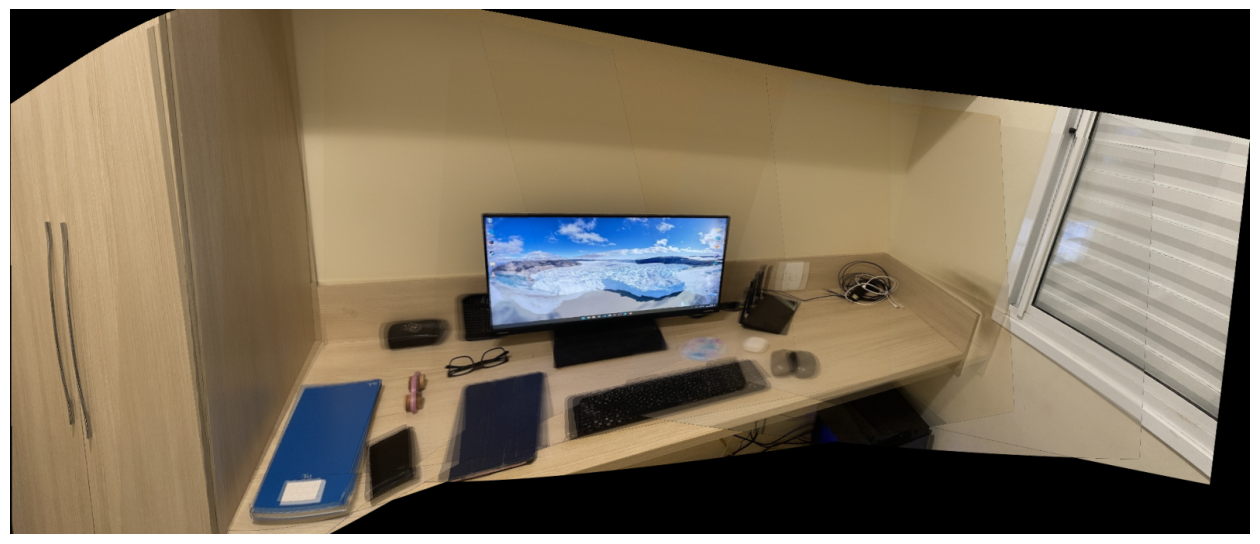

In [ ]:
from src.composition import cylindrical_stitching
from src.blending import average_blending, median_blending

warps, masks, info = cylindrical_stitching(images, order, homographies, 750)
print(info)
plot_image(average_blending(warps, masks))